In [210]:
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [211]:
print("All Libaries loaded")

All Libaries loaded


In [212]:
url = "http://api.worldbank.org/v2/country/all/indicator/FX.OWN.TOTL.ZS?date=2021&format=json&per_page=300"
response = requests.get(url)


In [213]:
print(response.status_code)

200


In [214]:
data = response.json()


In [215]:
print(type(data))

print(len(data))

<class 'list'>
2


In [216]:
print(data[0])


{'page': 1, 'pages': 1, 'per_page': 300, 'total': 266, 'sourceid': '2', 'lastupdated': '2026-04-08'}


In [217]:
print(data[1][0])

{'indicator': {'id': 'FX.OWN.TOTL.ZS', 'value': 'Account ownership at a financial institution or with a mobile-money-service provider (% of population ages 15+)'}, 'country': {'id': 'ZH', 'value': 'Africa Eastern and Southern'}, 'countryiso3code': 'AFE', 'date': '2021', 'value': None, 'unit': '', 'obs_status': '', 'decimal': 2}


In [218]:
records  = data[1]
real_data = [entry for entry in records if entry['value'] is not None]
print(f"Total entries: {len(records)}")
print(f"Entries with actual data: {len(real_data)}")

Total entries: 266
Entries with actual data: 144


In [219]:
df_wb = pd.DataFrame([
    {
        'country': entry['country']['value'],
        'country_code': entry['countryiso3code'],
        'year': entry['date'],
        'account_ownership': entry['value']
        }
    for entry in real_data

]
)
print(df_wb.head())

                                       country country_code  year  \
0                                   Arab World          ARB  2021   
1                          East Asia & Pacific          EAS  2021   
2  East Asia & Pacific (excluding high income)          EAP  2021   
3                                    Euro area          EMU  2021   
4                        Europe & Central Asia          ECS  2021   

   account_ownership  
0          40.210000  
1          82.850000  
2          79.701061  
3          98.510000  
4          89.570000  


In [220]:
df_wb.describe()

,account_ownership
count,144.000000
mean,70.205597
std,24.602815
min,5.831407
25%,49.577413
50%,73.425181
75%,94.897254
max,100.000000


In [221]:
df_wb.sort_values('account_ownership').head(10)


,country,country_code,year,account_ownership
122,South Sudan,SSD,2021,5.831407
22,Afghanistan,AFG,2021,9.653822
70,Iraq,IRQ,2021,18.565282
84,Lebanon,LBN,2021,20.703098
105,Pakistan,PAK,2021,20.980631
101,Nicaragua,NIC,2021,26.032803
52,"Egypt, Arab Rep.",EGY,2021,27.444006
117,Sierra Leone,SLE,2021,28.846604
62,Guinea,GIN,2021,30.440336
37,Cambodia,KHM,2021,33.394992


In [222]:
df_wb.sort_values('account_ownership', ascending=False).head(5)



,country,country_code,year,account_ownership
49,Denmark,DNK,2021,100.000000
66,Iceland,ISL,2021,100.000000
59,Germany,DEU,2021,99.976594
28,Austria,AUT,2021,99.950717
136,United Kingdom,GBR,2021,99.763274


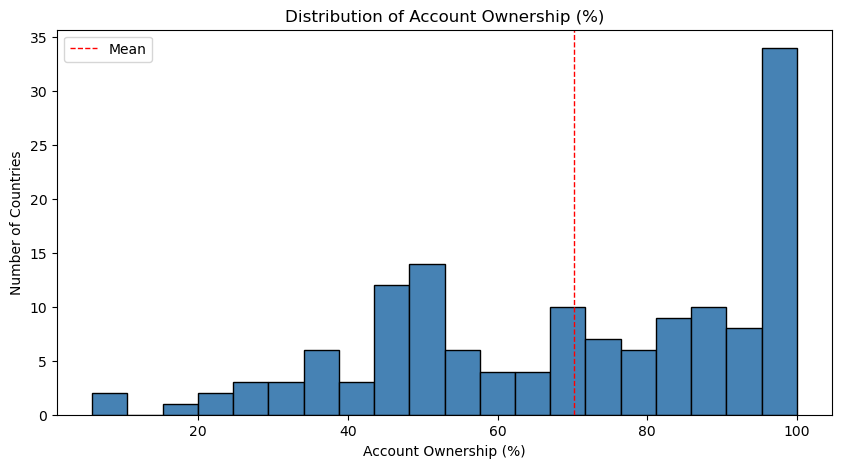

In [223]:
plt.figure(figsize=(10, 5))
plt.hist(df_wb['account_ownership'], bins=20, edgecolor='black',color='steelblue')
plt.title('Distribution of Account Ownership (%)')
plt.xlabel('Account Ownership (%)')
plt.ylabel('Number of Countries')
plt.axvline(df_wb['account_ownership'].mean(), color='red', linestyle='dashed', linewidth=1, label='Mean')
plt.legend()
plt.show()



In [224]:
print(df_wb[df_wb['account_ownership'] > 95].shape)

(34, 4)


## GDP Per Capita from 2000 to 2021


In [225]:
url_GDP_PC = "http://api.worldbank.org/v2/country/all/indicator/NY.GDP.PCAP.CD?date=2000:2021&format=json&per_page=6000"
response_gdp_pc = requests.get(url_GDP_PC)


In [226]:
print(response_gdp_pc.status_code)
data_gdp_pc = response_gdp_pc.json()

200


In [227]:
print(type(data_gdp_pc))
print(len(data_gdp_pc))

<class 'list'>
2


In [228]:
print(data_gdp_pc[1])

[{'indicator': {'id': 'NY.GDP.PCAP.CD', 'value': 'GDP per capita (current US$)'}, 'country': {'id': 'ZH', 'value': 'Africa Eastern and Southern'}, 'countryiso3code': 'AFE', 'date': '2021', 'value': 1562.41617477738, 'unit': '', 'obs_status': '', 'decimal': 1}, {'indicator': {'id': 'NY.GDP.PCAP.CD', 'value': 'GDP per capita (current US$)'}, 'country': {'id': 'ZH', 'value': 'Africa Eastern and Southern'}, 'countryiso3code': 'AFE', 'date': '2020', 'value': 1351.59166910879, 'unit': '', 'obs_status': '', 'decimal': 1}, {'indicator': {'id': 'NY.GDP.PCAP.CD', 'value': 'GDP per capita (current US$)'}, 'country': {'id': 'ZH', 'value': 'Africa Eastern and Southern'}, 'countryiso3code': 'AFE', 'date': '2019', 'value': 1507.08559963484, 'unit': '', 'obs_status': '', 'decimal': 1}, {'indicator': {'id': 'NY.GDP.PCAP.CD', 'value': 'GDP per capita (current US$)'}, 'country': {'id': 'ZH', 'value': 'Africa Eastern and Southern'}, 'countryiso3code': 'AFE', 'date': '2018', 'value': 1552.07372194919, 'uni

In [229]:
records_gdp_pc  = data_gdp_pc[1]
real_data_gdp_pc = [entry for entry in records_gdp_pc if entry['value'] is not None]
print(f"Total Entries for GDP  per Capita : {len(records_gdp_pc)}")
print(f"Entries with Actual data: {len(real_data_gdp_pc)}")

Total Entries for GDP  per Capita : 5852
Entries with Actual data: 5685


In [230]:
df_gdp_pc = pd.DataFrame([
    {
        'country': entry['country']['value'],
        'country_code' : entry['countryiso3code'],
        'year': entry['date'],
        'gdp_per_capita': entry['value']
    }
    for entry in real_data_gdp_pc
])

In [231]:
print(df_gdp_pc.head())

                       country country_code  year  gdp_per_capita
0  Africa Eastern and Southern          AFE  2021     1562.416175
1  Africa Eastern and Southern          AFE  2020     1351.591669
2  Africa Eastern and Southern          AFE  2019     1507.085600
3  Africa Eastern and Southern          AFE  2018     1552.073722
4  Africa Eastern and Southern          AFE  2017     1528.104224


In [232]:
df_gdp_pc.describe()

,gdp_per_capita
count,5685.000000
mean,14267.326864
std,22530.897876
min,109.593814
25%,1482.815663
50%,4788.833423
75%,17803.947177
max,223823.363960


In [233]:
df_gdp_pc.sort_values('gdp_per_capita').head(10)

,country,country_code,year,gdp_per_capita
2441,Ethiopia,ETH,2002,109.593814
1732,Burundi,BDI,2003,111.406683
2440,Ethiopia,ETH,2003,116.800491
2442,Ethiopia,ETH,2001,118.457204
1733,Burundi,BDI,2002,120.952309
2443,Ethiopia,ETH,2000,122.269203
1731,Burundi,BDI,2004,125.194965
1734,Burundi,BDI,2001,132.159555
2439,Ethiopia,ETH,2004,133.169813
1735,Burundi,BDI,2000,134.537862


In [234]:
df_gdp_pc.sort_values('year').head(5)

,country,country_code,year,gdp_per_capita
5684,Zimbabwe,ZWE,2000,562.833757
901,Small states,SST,2000,4846.982126
3511,Lithuania,LTU,2000,3300.636349
2509,Finland,FIN,2000,24335.922508
4986,St. Vincent and the Grenadines,VCT,2000,3768.955366


In [235]:
df_merged = df_gdp_pc.merge(df_gdp_pc, on='country_code')
print(df_merged.shape)
df_merged.head()

(129969, 7)


,country_x,country_code,year_x,gdp_per_capita_x,country_y,year_y,gdp_per_capita_y
0,Africa Eastern and Southern,AFE,2021,1562.416175,Africa Eastern and Southern,2021,1562.416175
1,Africa Eastern and Southern,AFE,2021,1562.416175,Africa Eastern and Southern,2020,1351.591669
2,Africa Eastern and Southern,AFE,2021,1562.416175,Africa Eastern and Southern,2019,1507.085600
3,Africa Eastern and Southern,AFE,2021,1562.416175,Africa Eastern and Southern,2018,1552.073722
4,Africa Eastern and Southern,AFE,2021,1562.416175,Africa Eastern and Southern,2017,1528.104224


In [236]:
print(df_gdp_pc['country_code'].nunique())


259


In [237]:
df_gdp_2021 = df_gdp_pc[df_gdp_pc['year'] == '2021']
print(df_gdp_2021.shape)

(258, 4)


In [238]:
df_merged = df_wb.merge(df_gdp_2021, on='country_code')
print(df_merged.shape)
df_merged.head()


(155, 7)


,country_x,country_code,year_x,account_ownership,country_y,year_y,gdp_per_capita
0,Arab World,ARB,2021,40.210000,Arab World,2021,6697.414985
1,East Asia & Pacific,EAS,2021,82.850000,East Asia & Pacific,2021,13336.484167
2,East Asia & Pacific (excluding high income),EAP,2021,79.701061,East Asia & Pacific (excluding high income),2021,9974.578297
3,Euro area,EMU,2021,98.510000,Euro area,2021,42984.569741
4,Europe & Central Asia,ECS,2021,89.570000,Europe & Central Asia,2021,27664.891408


In [239]:
df_merged = df_merged.drop(columns=['country_y', 'year_y'])
df_merged = df_merged.rename(columns={'country_x': 'country', 'year_x': 'year'})
print(df_merged.columns)

Index(['country', 'country_code', 'year', 'account_ownership',
       'gdp_per_capita'],
      dtype='object')


In [240]:
df_world_gdp = df_gdp_pc.groupby('year')['gdp_per_capita'].mean()
print(df_world_gdp)

year
2000     7563.714187
2001     7571.516244
2002     8175.551954
2003     9397.095856
2004    10683.627339
2005    11581.680478
2006    12941.878955
2007    14721.778120
2008    15787.123120
2009    14310.259616
2010    15046.841615
2011    16566.449702
2012    16450.714381
2013    17007.388694
2014    17312.060995
2015    15660.924513
2016    15783.784841
2017    16592.499881
2018    17573.925150
2019    17537.480522
2020    16283.153813
2021    18803.437185
Name: gdp_per_capita, dtype: float64


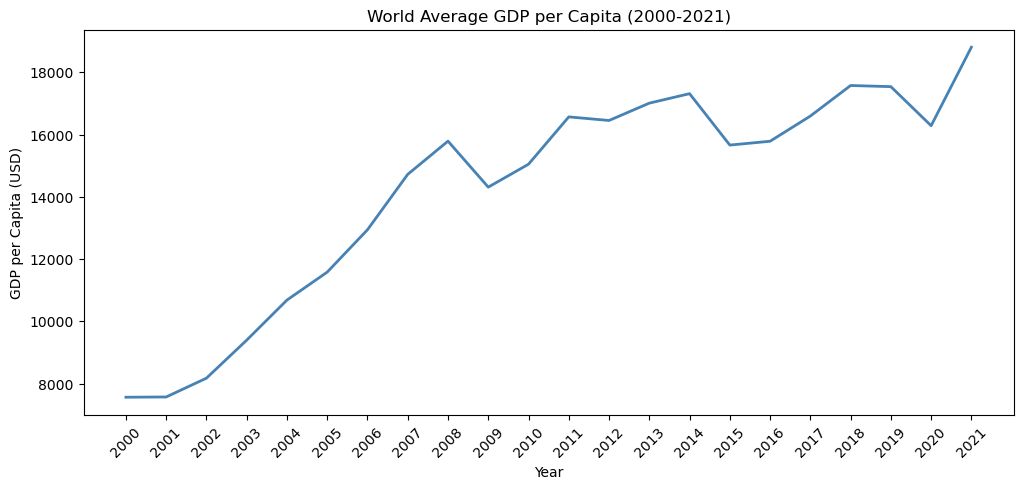

In [241]:
plt.figure(figsize=(12, 5))
plt.plot(df_world_gdp.index, df_world_gdp.values, color='steelblue', linewidth=2)
plt.title('World Average GDP per Capita (2000-2021)')
plt.xlabel('Year')
plt.ylabel('GDP per Capita (USD)')
plt.xticks(rotation=45)
plt.show()

Access to electricity [AtE] (% of population)

In [242]:
url_ATE = "http://api.worldbank.org/v2/country/all/indicator/EG.ELC.ACCS.ZS?date=2021&format=json&per_page=6000"
response_ate = requests.get(url_ATE)

In [243]:
data_ate = response_ate.json()

In [244]:
print(type(data_ate))
print(len(data_ate))
print(data_ate[1])

<class 'list'>
2
[{'indicator': {'id': 'EG.ELC.ACCS.ZS', 'value': 'Access to electricity (% of population)'}, 'country': {'id': 'ZH', 'value': 'Africa Eastern and Southern'}, 'countryiso3code': 'AFE', 'date': '2021', 'value': 48.1272110400485, 'unit': '', 'obs_status': '', 'decimal': 1}, {'indicator': {'id': 'EG.ELC.ACCS.ZS', 'value': 'Access to electricity (% of population)'}, 'country': {'id': 'ZI', 'value': 'Africa Western and Central'}, 'countryiso3code': 'AFW', 'date': '2021', 'value': 54.368598708444, 'unit': '', 'obs_status': '', 'decimal': 1}, {'indicator': {'id': 'EG.ELC.ACCS.ZS', 'value': 'Access to electricity (% of population)'}, 'country': {'id': '1A', 'value': 'Arab World'}, 'countryiso3code': 'ARB', 'date': '2021', 'value': 90.4340947732985, 'unit': '', 'obs_status': '', 'decimal': 1}, {'indicator': {'id': 'EG.ELC.ACCS.ZS', 'value': 'Access to electricity (% of population)'}, 'country': {'id': 'S3', 'value': 'Caribbean small states'}, 'countryiso3code': 'CSS', 'date': '2

In [245]:
records_ate  = data_ate[1]
real_data_ate = [entry for entry in records_ate if entry['value'] is not None]
print(f"Total Entries for Access to Electricity: {len(records_ate)}")
print(f"Entries with Valid Data: {len(real_data_ate)}")

Total Entries for Access to Electricity: 266
Entries with Valid Data: 263


In [246]:
df_ate = pd.DataFrame([
    {
        'country': entry['country']['value'],
        'country_code': entry['countryiso3code'],
        'year': entry['date'],
        'access_to_electricity': entry['value']
    }
    for entry in real_data_ate
])
print(df_ate.head())

                          country country_code  year  access_to_electricity
0     Africa Eastern and Southern          AFE  2021              48.127211
1      Africa Western and Central          AFW  2021              54.368599
2                      Arab World          ARB  2021              90.434095
3          Caribbean small states          CSS  2021              98.174699
4  Central Europe and the Baltics          CEB  2021              99.987012


In [247]:
df_ate.describe()

,access_to_electricity
count,263.000000
mean,86.855188
std,22.889985
min,7.700000
25%,85.985409
50%,99.976387
75%,100.000000
max,100.000000


In [248]:
# Merge Access to Electricity with GDP per Capita for 2021

df_gdp_pc2021 = df_gdp_pc[df_gdp_pc['year'] == '2021']
df_gdp_pc2021.head()

,country,country_code,year,gdp_per_capita
0,Africa Eastern and Southern,AFE,2021,1562.416175
22,Africa Western and Central,AFW,2021,2112.794076
44,Arab World,ARB,2021,6697.414985
66,Caribbean small states,CSS,2021,13995.269492
88,Central Europe and the Baltics,CEB,2021,19223.927403


In [249]:
print(len(df_gdp_pc2021))
print(len(df_ate))
print(len(df_wb))

258
263


In [263]:
df_merge_ate2021 = df_gdp_pc2021.merge(df_ate, on='country_code')
print(df_merge_ate2021.head())

print(df_merge_ate2021.columns)
print(df_merge_ate2021.shape[0])

                        country_x country_code year_x  gdp_per_capita  \
0     Africa Eastern and Southern          AFE   2021     1562.416175   
1      Africa Western and Central          AFW   2021     2112.794076   
2                      Arab World          ARB   2021     6697.414985   
3          Caribbean small states          CSS   2021    13995.269492   
4  Central Europe and the Baltics          CEB   2021    19223.927403   

                        country_y year_y  access_to_electricity  
0     Africa Eastern and Southern   2021              48.127211  
1      Africa Western and Central   2021              54.368599  
2                      Arab World   2021              90.434095  
3          Caribbean small states   2021              98.174699  
4  Central Europe and the Baltics   2021              99.987012  
Index(['country_x', 'country_code', 'year_x', 'gdp_per_capita', 'country_y',
       'year_y', 'access_to_electricity'],
      dtype='object')
268


In [259]:
# Drop value

df_merge_ate2021 = df_merge_ate2021.drop(columns=['country_y', 'year_y'])
df_merge_ate2021 = df_merge_ate2021.rename(columns={'country_x': 'country', 'year_x': 'year'})
print(df_merge_ate2021.columns)

Index(['country', 'country_code', 'year', 'gdp_per_capita',
       'access_to_electricity'],
      dtype='object')


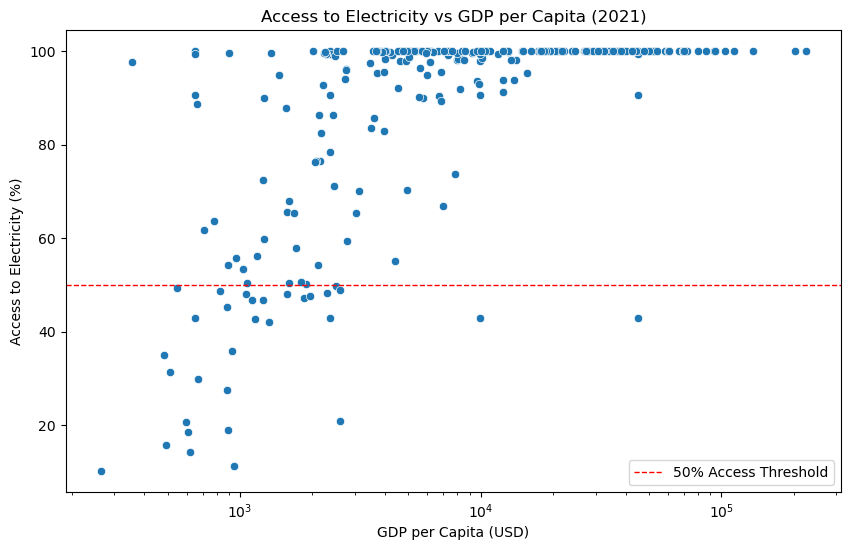

In [268]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_merge_ate2021, x='gdp_per_capita', y='access_to_electricity')
plt.title('Access to Electricity vs GDP per Capita (2021)')
plt.xlabel('GDP per Capita (USD)')
plt.ylabel('Access to Electricity (%)')
plt.xscale('log')
plt.axhline(50, color='red', linestyle='dashed', linewidth=1, label='50% Access Threshold')
plt.legend()    
plt.show()

In [271]:
url_countries = "http://api.worldbank.org/v2/country?format=json&per_page=300"
response_countries = requests.get(url_countries)
data_countries = response_countries.json()


{'id': 'ABW', 'iso2Code': 'AW', 'name': 'Aruba', 'region': {'id': 'LCN', 'iso2code': 'ZJ', 'value': 'Latin America & Caribbean '}, 'adminregion': {'id': '', 'iso2code': '', 'value': ''}, 'incomeLevel': {'id': 'HIC', 'iso2code': 'XD', 'value': 'High income'}, 'lendingType': {'id': 'LNX', 'iso2code': 'XX', 'value': 'Not classified'}, 'capitalCity': 'Oranjestad', 'longitude': '-70.0167', 'latitude': '12.5167'}


In [274]:
print(data_countries[1])
real_data_coun = [entry for entry in data_countries[1] if entry['region']['value'] != 'Aggregates']
print(f"Total Country Entries: {len(data_countries[1])}")
print(f"Valid Country Entries (excluding Aggregates): {len(real_data_coun)}")

[{'id': 'ABW', 'iso2Code': 'AW', 'name': 'Aruba', 'region': {'id': 'LCN', 'iso2code': 'ZJ', 'value': 'Latin America & Caribbean '}, 'adminregion': {'id': '', 'iso2code': '', 'value': ''}, 'incomeLevel': {'id': 'HIC', 'iso2code': 'XD', 'value': 'High income'}, 'lendingType': {'id': 'LNX', 'iso2code': 'XX', 'value': 'Not classified'}, 'capitalCity': 'Oranjestad', 'longitude': '-70.0167', 'latitude': '12.5167'}, {'id': 'AFE', 'iso2Code': 'ZH', 'name': 'Africa Eastern and Southern', 'region': {'id': 'NA', 'iso2code': 'NA', 'value': 'Aggregates'}, 'adminregion': {'id': '', 'iso2code': '', 'value': ''}, 'incomeLevel': {'id': 'NA', 'iso2code': 'NA', 'value': 'Aggregates'}, 'lendingType': {'id': '', 'iso2code': '', 'value': 'Aggregates'}, 'capitalCity': '', 'longitude': '', 'latitude': ''}, {'id': 'AFG', 'iso2Code': 'AF', 'name': 'Afghanistan', 'region': {'id': 'MEA', 'iso2code': 'ZQ', 'value': 'Middle East, North Africa, Afghanistan & Pakistan'}, 'adminregion': {'id': 'MNA', 'iso2code': 'XQ',

In [276]:
df_coun = pd.DataFrame([
    {
        'country': entry['name'],
        'country_code': entry['id'],
        'region': entry['region']['value']
    }
    for entry in real_data_coun
])

print(df_coun.head())

       country country_code                                             region
0        Aruba          ABW                         Latin America & Caribbean 
1  Afghanistan          AFG  Middle East, North Africa, Afghanistan & Pakistan
2       Angola          AGO                                Sub-Saharan Africa 
3      Albania          ALB                              Europe & Central Asia
4      Andorra          AND                              Europe & Central Asia


In [277]:
print(df_coun['region'].unique())

['Latin America & Caribbean '
 'Middle East, North Africa, Afghanistan & Pakistan' 'Sub-Saharan Africa '
 'Europe & Central Asia' 'East Asia & Pacific' 'South Asia'
 'North America']


In [283]:
g7 = ['USA', 'GBR', 'DEU', 'FRA', 'JPN', 'ITA', 'CAN']

In [285]:
df_gdp_g7 = df_gdp_pc.merge(df_wb[df_wb['country_code'].isin(g7)])

print(df_gdp_g7.head())

   country country_code  year  gdp_per_capita  account_ownership
0   Canada          CAN  2021    52886.661637          99.634615
1   France          FRA  2021    43725.099952          99.244295
2  Germany          DEU  2021    52349.245999          99.976594
3    Italy          ITA  2021    36852.542541          97.294557
4    Japan          JPN  2021    40094.559980          98.489420


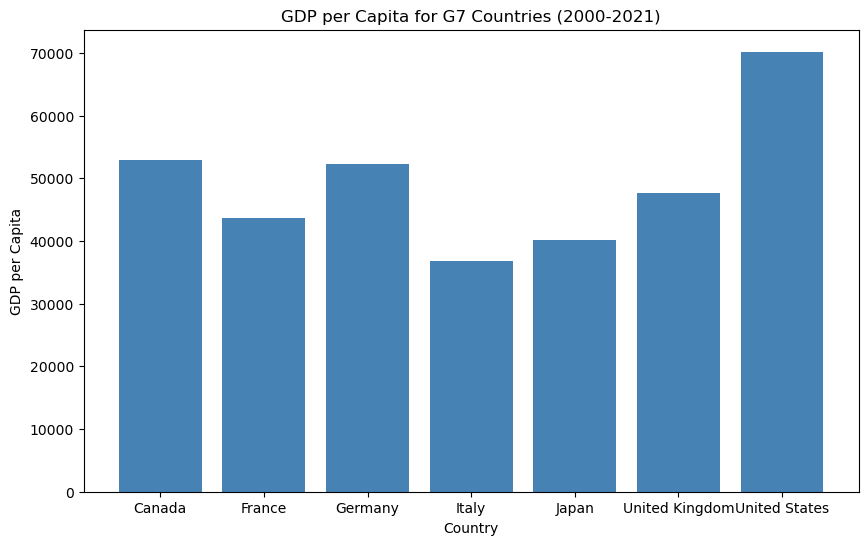

In [290]:
plt.figure(figsize=(10, 6))
plt.bar(df_gdp_g7['country'], df_gdp_g7['gdp_per_capita'], color='steelblue')
plt.title('GDP per Capita for G7 Countries (2000-2021)')
plt.xlabel('Country')
plt.ylabel('GDP per Capita')
plt.show()

(7, 7)

GDP per capita for last few years for G7


In [295]:
df_gdppc_g7 = df_gdp_pc[df_gdp_pc['country_code'].isin(g7)]

print(df_gdppc_g7.head())

     country country_code  year  gdp_per_capita
1802  Canada          CAN  2021    52886.661637
1803  Canada          CAN  2020    43537.839299
1804  Canada          CAN  2019    46352.869345
1805  Canada          CAN  2018    46539.176157
1806  Canada          CAN  2017    45129.628117


C:\Users\NEW\AppData\Local\Temp\ipykernel_37644\4257394711.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_gdppc_g7['year'] = df_gdppc_g7['year'].astype(int)


Text(0.5, 1.0, 'GDP per Capita Over Time for G7 Countries')

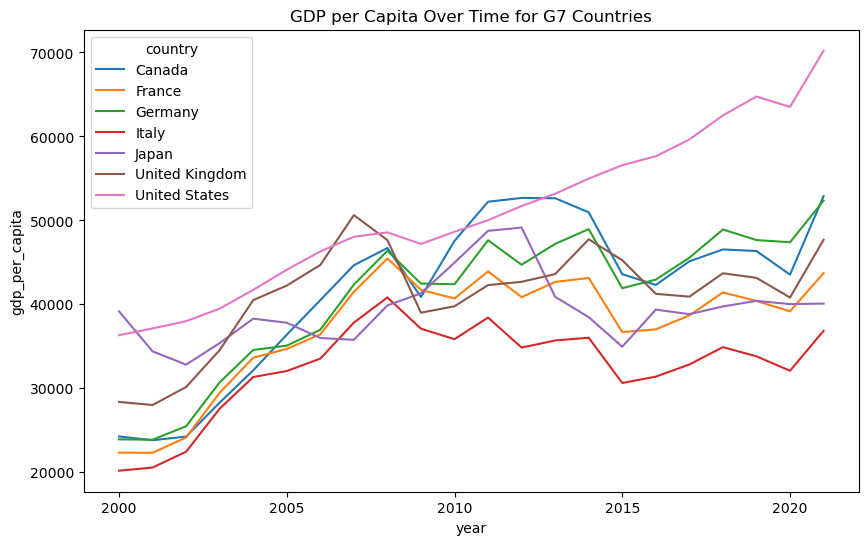

In [298]:
df_gdppc_g7['year'] = df_gdppc_g7['year'].astype(int)

plt.figure(figsize=(10, 6))
sns.lineplot(data=df_gdppc_g7, x='year', y='gdp_per_capita', hue='country')
plt.title('GDP per Capita Over Time for G7 Countries')

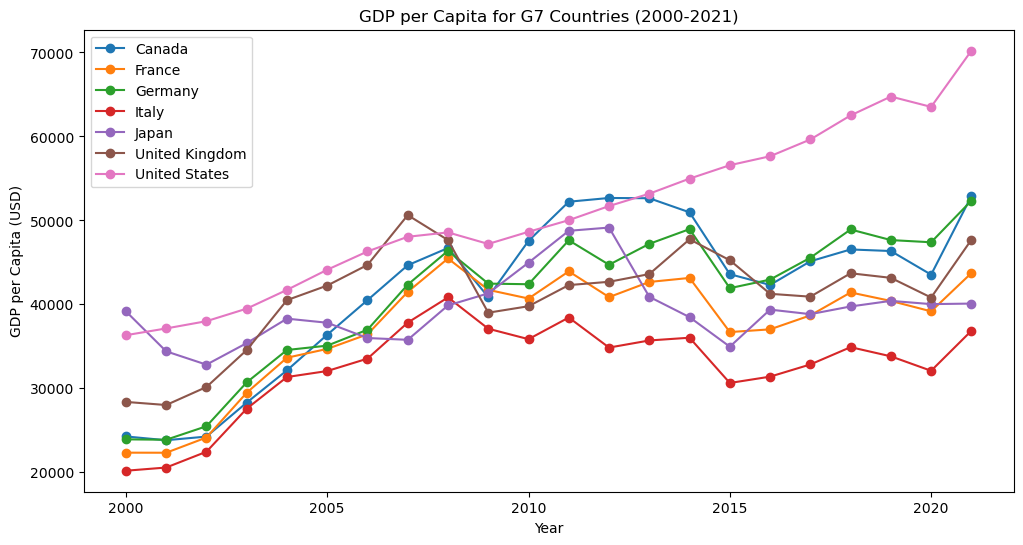

In [ ]:
plt.figure(figsize=(12, 6))

for country in df_gdppc_g7['country'].unique():
    data = df_gdppc_g7[df_gdppc_g7['country'] == country]
    plt.plot(data['year'], data['gdp_per_capita'], marker='o', label=country)

plt.title('GDP per Capita for G7 Countries (2000-2021)')
plt.xlabel('Year')
plt.ylabel('GDP per Capita (USD)')
plt.legend()
plt.show()

In [301]:
for country in df_gdppc_g7['country'].unique():
    print(country)

Canada
France
Germany
Italy
Japan
United Kingdom
United States
